>>> Processing REST condition for sub-001...


/mnt/movement/users/jaizor/.local/lib/python3.13/site-packages/lcmv_xtra/source_estimation.py:66: RuntimeWarning: This filename (/mnt/movement/users/jaizor/xtra/derivatives/eeg/rest/clean/sub-01/rest_off/rest_off_sub-01_c_eeg_mkit_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(ica_file, preload=True)


>>> Processing MOVE condition for sub-001...
>>> Extracting signal for R_4_ROI...
Sampling Frequency: 500.0 Hz | Rest Samples: 30002 | Move Samples: 20252
>>> Generating ML features (Z-score -> Epoch -> PSD)...

--- ML DataFrame Head ---
   epoch     delta     theta     alpha      beta  low_gamma  high_gamma target
0      0  0.586003  0.339195  0.057729  0.104238   0.042255    0.160176   rest
1      1  0.208336  0.217829  0.080813  0.120161   0.175304    0.314250   rest
2      2  0.137171  0.107324  0.032857  0.137423   0.279570    0.424465   rest
3      3  0.054048  0.079919  0.020872  0.066212   0.083113    0.180344   rest
4      4  0.456933  0.073518  0.034018  0.101790   0.088699    0.159331   rest

Total epochs generated: 262
>>> Generating visualizations...


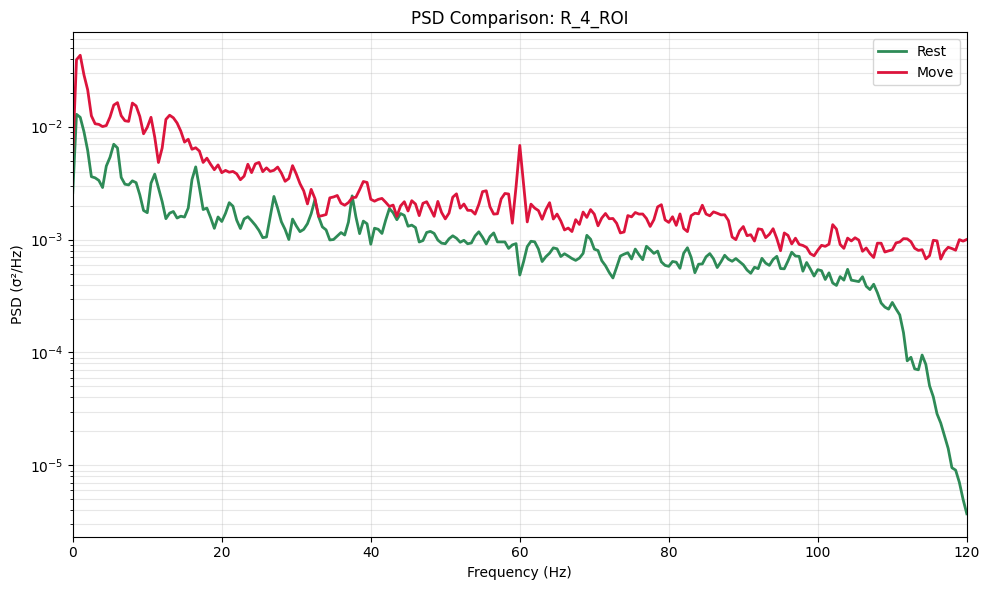

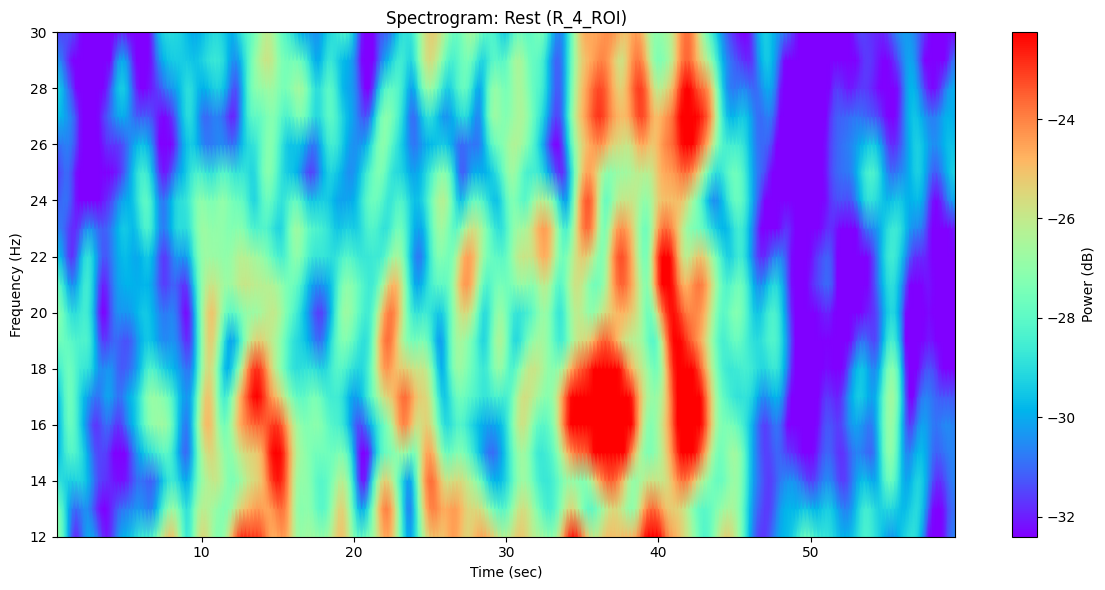

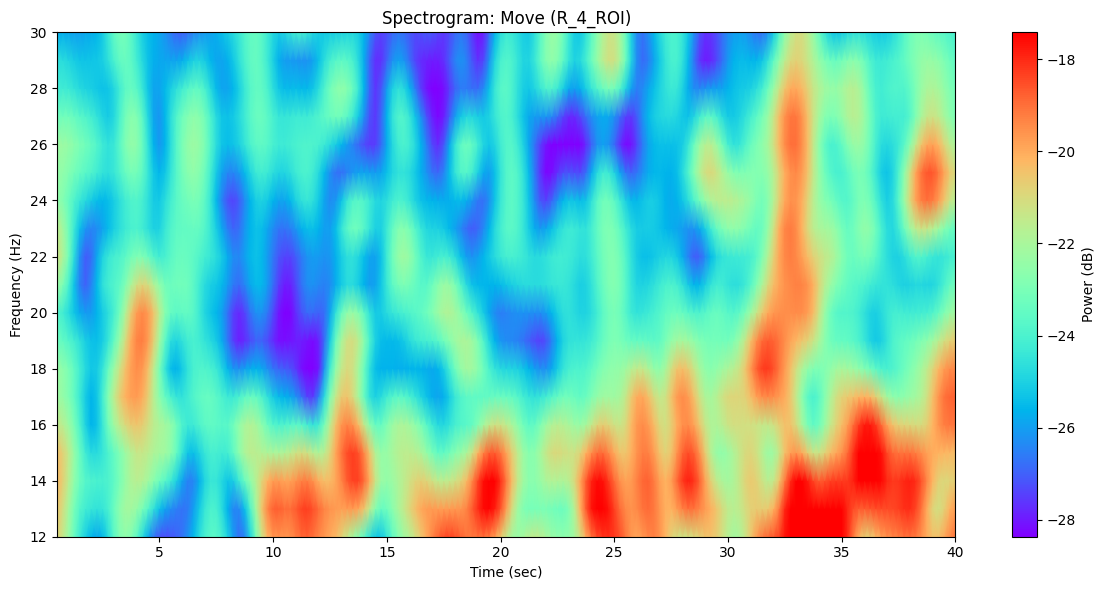

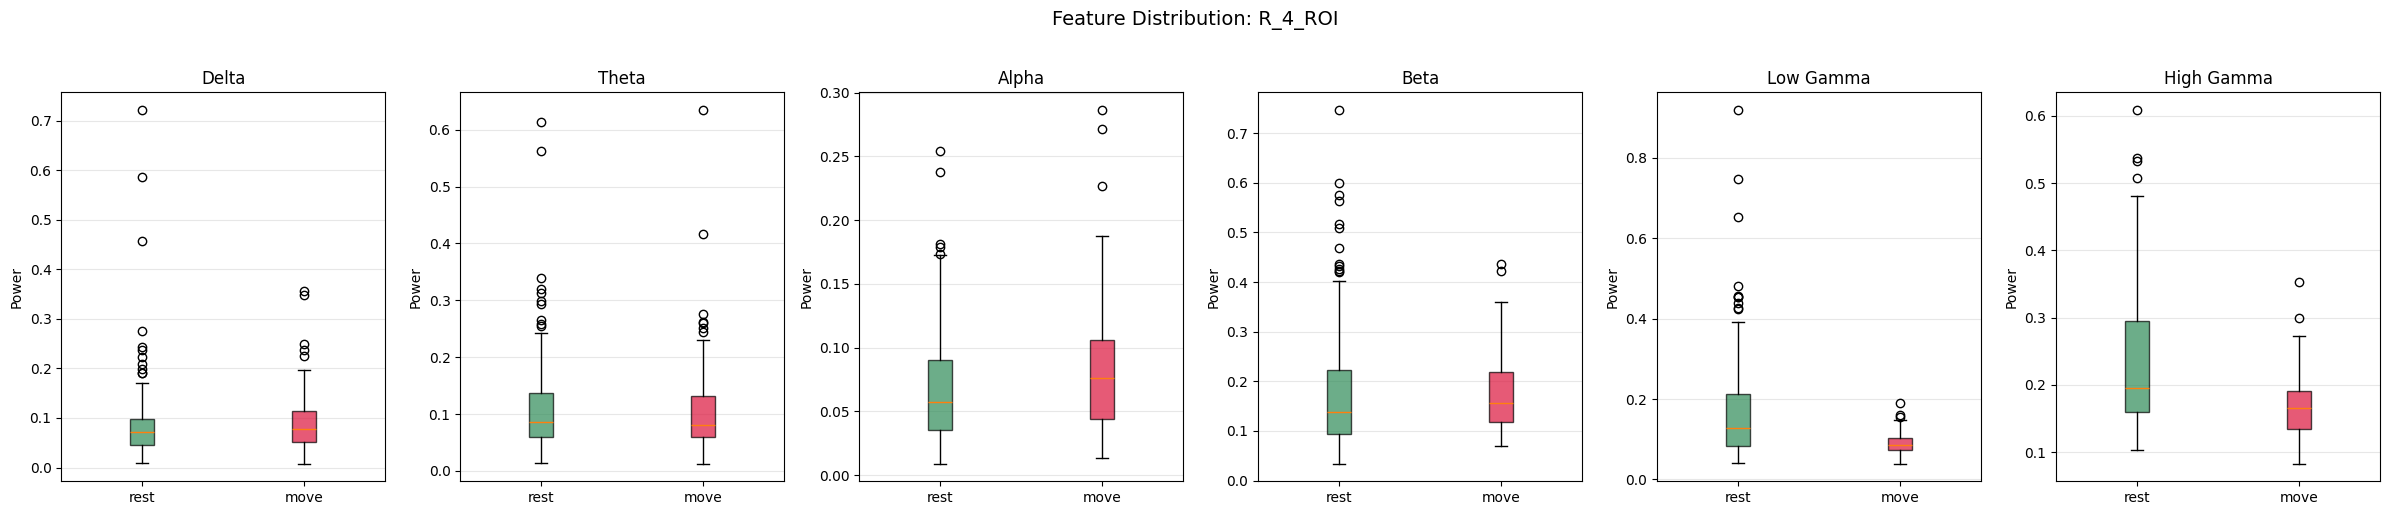


✅ Tutorial Complete. Results saved to: processed_ml_data/sub-001_R_4_ROI_ML_Features.csv


In [ ]:
# Feature Engineering ML Framework 

import numpy as np
from pathlib import Path
import lcmv_stats as ls
from lcmv_xtra import execute_source_estimation
from lcmv_xtra.cimt_atlas import cimt_extraction

# =============================================================================
# 1. CONFIGURATION
# =============================================================================
PROJECT_BASE = Path("folder_path")
FS_DIR = Path("_fs")

SUBJECT_ID = "sub-001"
TARGET_ROI = "R_4_ROI"  # Right Primary Motor Cortex (Area 4)

REST_TASK = "rest_off"
MOVE_TASK = "bima_off"

REST_SOURCE_DIR = Path("rest_sub-01_eyes_closed_eeg.fif")
MOVE_SOURCE_DIR = Path("move_sub-01_bimanual_move_eeg.fif")

# =============================================================================
# 2. SOURCE ESTIMATION & CIMT EXTRACTION (REST)
# =============================================================================
print(f">>> Processing REST condition for {SUBJECT_ID}...")

rest_metadata = execute_source_estimation(
    project_base=PROJECT_BASE,
    subject_id=SUBJECT_ID,
    task=REST_TASK,
    ica_file_path=REST_SOURCE_DIR,
    fsaverage_dir=FS_DIR,
    verbose=False
)

rest_tc, _ = cimt_extraction(
    subject_output_dir=Path(rest_metadata['subject_output']),
    fsaverage_dir=FS_DIR,
    verbose=False
)

# Extract FS directly from metadata returned by source estimation
fs = float(rest_metadata['sfreq_hz'])

# =============================================================================
# 3. SOURCE ESTIMATION & CIMT EXTRACTION (MOVE)
# =============================================================================
print(f">>> Processing MOVE condition for {SUBJECT_ID}...")

move_metadata = execute_source_estimation(
    project_base=PROJECT_BASE,
    subject_id=SUBJECT_ID,
    task=MOVE_TASK,
    ica_file_path=MOVE_SOURCE_DIR,
    fsaverage_dir=FS_DIR,
    verbose=False
)

move_tc, _ = cimt_extraction(
    subject_output_dir=Path(move_metadata['subject_output']),
    fsaverage_dir=FS_DIR,
    verbose=False
)

# =============================================================================
# 4. ROI SELECTION & SIGNAL EXTRACTION
# =============================================================================
print(f">>> Extracting signal for {TARGET_ROI}...")

roi_idx = ls.get_roi_index(TARGET_ROI)

rest_signal = rest_tc[roi_idx, :]
move_signal = move_tc[roi_idx, :]

print(f"Sampling Frequency: {fs} Hz | Rest Samples: {len(rest_signal)} | Move Samples: {len(move_signal)}")

# =============================================================================
# 5. MACHINE LEARNING FEATURE ENGINEERING
# =============================================================================
print(">>> Generating ML features (Z-score -> Epoch -> PSD)...")

df_ml = ls.process_signal_to_ml_dataframe(
    rest_signal=rest_signal,
    move_signal=move_signal,
    fs=fs,
    epoch_duration=1.5,
    overlap_frac=0.75
)

print("\n--- ML DataFrame Head ---")
print(df_ml.head())
print(f"\nTotal epochs generated: {len(df_ml)}")

# =============================================================================
# 6. VISUALIZATION
# =============================================================================
print(">>> Generating visualizations...")

ls.plot_psd_comparison(
    signals={"Rest": rest_signal, "Move": move_signal},
    fs=fs,
    title=f"PSD Comparison: {TARGET_ROI}"
)

ls.plot_spectrogram(rest_signal, fs, title=f"Spectrogram: Rest ({TARGET_ROI})")
ls.plot_spectrogram(move_signal, fs, title=f"Spectrogram: Move ({TARGET_ROI})")

ls.plot_feature_distribution(
    df_features=df_ml,
    title=f"Feature Distribution: {TARGET_ROI}"
)

# =============================================================================
# 7. SAVE RESULTS
# =============================================================================
output_path = Path("./processed_ml_data") / f"{SUBJECT_ID}_{TARGET_ROI}_ML_Features.csv"
output_path.parent.mkdir(exist_ok=True)
df_ml.to_csv(output_path, index=False)
print(f"\n✅ Tutorial Complete. Results saved to: {output_path}")